# AI-Based PPE Safety Compliance Monitoring System
**Stack:** YOLO26 · ByteTrack · OpenCV · Gemini API · Python

### Pipeline
`Video Input → Frame Extraction → YOLO26 Detection → ByteTrack Tracking → Compliance Check → Gemini Reasoning → Outputs`

### Outputs
- `output/output_detection.mp4` — Annotated video
- `output/output_log.json` — Gemini JSON report
- `output/coordinates.csv` — Worker movement log
- `output/radar_map.png` — 2D trajectory scatter plot

# **Install Dependencies**

In [1]:
!pip install ultralytics opencv-python-headless google-genai matplotlib pandas numpy -q
print("✅ All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00
✅ All dependencies installed.


# **Import Libraries & Configuration**

In [ ]:
import cv2, os, json, csv, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO
from google import genai
from google.genai import types
from IPython.display import display, Image as IPImage

# ── CONFIGURATION (edit these) ─────────────────────────────────────────────────
GEMINI_API_KEY  = ""   # 🔑 Insert your key
INPUT_VIDEO     = "input5.mp4"   # 📂 Upload your video here
MODEL_WEIGHTS   = "yolo26n.pt"                 # yolo26n.pt / custom.pt
CONFIDENCE      = 0.10
FPS_SAMPLE      = 2                            # frames per second to process
MAX_WIDTH       = 640
BLUR_KERNEL     = (3, 3)

os.makedirs("output", exist_ok=True)

# Colour palette per class
COLORS = {
    "person":          (255, 200,  50),
    "worker_helmet":   (  0, 255,   0),
    "engineer_helmet": ( 50, 200, 255),
    "officer_helmet":  (255, 140,   0),
    "no_helmet":       (  0,   0, 255),
    "safety_vest":     (  0, 230, 118),
    "gloves":          (200, 100, 255),
    "boots":           (255,  80, 180),
    "suitcase":        (120, 120, 120),
    "default":         (200, 200, 200),
}

# Map COCO class ids → PPE labels (yolo26n trained on COCO)
COCO_MAP = {
    0: "person", 26: "suitcase",
    # helmet classes are inferred via Gemini for generic COCO weights
}

print("✅ Config loaded.")
print(f"   Model  : {MODEL_WEIGHTS}")
print(f"   Video  : {INPUT_VIDEO}")
print(f"   FPS    : {FPS_SAMPLE}")

✅ Config loaded.
   Model  : yolo26n.pt
   Video  : input5.mp4
   FPS    : 2


**Phase 1: Video Processing**

In [79]:
class VideoHandler:
    def __init__(self, input_path, output_path=None, target_fps=FPS_SAMPLE):
        self.input_path = input_path
        self.output_path = output_path
        self.target_fps = target_fps
        self.cap = cv2.VideoCapture(input_path)

        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.frame_skip = max(1, int(self.fps / target_fps)) if self.fps > 0 else 1

        # Read first frame to get size
        ret, frame = self.cap.read()
        if ret:
            self.orig_h, self.orig_w = frame.shape[:2]
            self.scale = MAX_WIDTH / self.orig_w
            self.new_w = MAX_WIDTH
            self.new_h = int(self.orig_h * self.scale)
        self.cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            self.writer = cv2.VideoWriter(output_path, fourcc, target_fps, (self.new_w, self.new_h))

    def process_frame(self, frame):
        # Resize
        frame = cv2.resize(frame, (self.new_w, self.new_h))
        # Gaussian Blur
        frame = cv2.GaussianBlur(frame, BLUR_KERNEL, 0)
        return frame

**Phase 2: PPE Detection**

In [80]:
class PPEDetector:
    def __init__(self, model_path=MODEL_WEIGHTS):
        print(f"Loading YOLO model: {model_path}...")
        self.model = YOLO(model_path)

    def detect(self, frame):
        # We run standard detection just to get the raw results format
        results = self.model(frame, conf=CONFIDENCE, verbose=False)
        return results[0]

**Phase 3: PPE Tracking**

In [81]:
class PPETracker:
    def __init__(self, detector):
        self.detector = detector

    def track_frame(self, frame):
        # ByteTrack integration: persist=True tracks objects across frames
        results = self.detector.model.track(
            frame,
            persist=True,
            tracker="bytetrack.yaml",
            conf=CONFIDENCE,
            verbose=False
        )
        return results[0]

**Phase 4: Compliance Logic & Visualization**

In [82]:
class Visualizer:
    @staticmethod
    def draw(frame, results, frame_count):
        annotated_frame = frame.copy()

        boxes = results.boxes
        if boxes is None or len(boxes) == 0:
            return annotated_frame

        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])

            # Use ByteTrack ID if available
            track_id = int(box.id[0]) if box.id is not None else -1

            # Map COCO classes to our PPE classes for visualization
            class_name = COCO_MAP.get(cls_id, "default")

            # Determine color (default to red if generic 'person')
            color = COLORS.get(class_name, COLORS["default"])
            if class_name == "person":
                color = COLORS["no_helmet"] # Flag person for Gemini to analyze

            # Draw BBox
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 4)

            # Label
            label = f"ID:{track_id} {class_name} {conf:.2f}"
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
            cv2.rectangle(annotated_frame, (x1, y1 - 30), (x1 + w, y1), color, -1)
            cv2.putText(annotated_frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        return annotated_frame

class PPELogger:
    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.data = []
        with open(self.csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['frame', 'worker_id', 'x', 'y', 'class'])

    def log_frame(self, frame_idx, results):
        boxes = results.boxes
        if boxes is None: return

        for box in boxes:
            track_id = int(box.id[0]) if box.id is not None else -1
            cls_id = int(box.cls[0])
            class_name = COCO_MAP.get(cls_id, "person")

            # Center coordinates
            x1, y1, x2, y2 = map(float, box.xyxy[0])
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

            self.data.append([frame_idx, track_id, cx, cy, class_name])

        # Append to CSV
        with open(self.csv_path, 'a', newline='') as f:
            writer = csv.writer(f)
            for d in self.data[-len(boxes):]:
                writer.writerow(d)

**Phase 5: Gemini API Integration**

In [83]:
class GeminiAnalyzer:
    def __init__(self, api_key):
        self.client = genai.Client(api_key=api_key)
        self.model_name = "gemini-3.1-flash-lite"

    def analyze_video(self, video_path):
        print(f"⬆️ Uploading {video_path} to Gemini...")
        video_file = self.client.files.upload(file=video_path)

        while video_file.state.name == "PROCESSING":
            print(".", end="", flush=True)
            time.sleep(3)
            video_file = self.client.files.get(name=video_file.name)

        if video_file.state.name == "FAILED":
            raise Exception("Video processing failed.")

        print("\n✅ Video processed. Running safety reasoning...")

        prompt = """Analyze this workplace safety video carefully.
        Tasks:
        1. Detect workers without helmets.
        2. Identify helmet types (worker_helmet, engineer_helmet, officer_helmet).
        3. Detect PPE violations (missing vest, no helmet).
        4. Track worker movement behavior.
        5. Detect unsafe actions or restricted area entry.
        6. Return ONLY valid JSON output.

        Required JSON structure:
        {
          "site_status": "safe or unsafe",
          "workers_detected": integer,
          "helmet_violations": integer,
          "workers": [
            {
              "worker_id": integer,
              "helmet_type": "string",
              "ppe_violation": boolean,
              "movement_summary": "string",
              "coordinates_detected": true,
              "safety_status": "safe or unsafe"
            }
          ],
          "overall_summary": "string"
        }
        """

        response = self.client.models.generate_content(
            model=self.model_name,
            contents=[video_file, prompt]
        )

        try:
            # Clean JSON markdown if present
            raw_text = response.text.strip()
            if raw_text.startswith("```json"):
                raw_text = raw_text[7:-3]
            data = json.loads(raw_text)
            return data
        except Exception as e:
            print("Failed to parse JSON. Raw output:")
            print(response.text)
            return {"error": "JSON parse failed", "raw": response.text}


**Main Pipeline Execution**

In [84]:
# Initialize modules
try:
    video = VideoHandler(INPUT_VIDEO, "output/output_detection.mp4", target_fps=FPS_SAMPLE)
    detector = PPEDetector(MODEL_WEIGHTS)
    tracker = PPETracker(detector)
    logger = PPELogger("output/coordinates.csv")

    sample_frames = []
    frame_idx = 0

    print("🚀 Starting Pipeline...")
    while True:
        ret, frame = video.cap.read()
        if not ret: break

        # Skip frames to match target FPS
        if frame_idx % video.frame_skip != 0:
            frame_idx += 1
            continue

        # Phase 1: Preprocess
        proc_frame = video.process_frame(frame)

        # Phase 2 & 3: Detect & Track
        results = tracker.track_frame(proc_frame)

        # Phase 4: Logging & Viz
        logger.log_frame(frame_idx, results)
        annotated = Visualizer.draw(proc_frame, results, frame_idx)

        # Save video frame
        if video.output_path:
            video.writer.write(annotated)

        # Save some samples for display
        if len(sample_frames) < 6 and frame_idx % int(max(1, video.fps)) == 0:
            sample_frames.append(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

        frame_idx += 1

    if video.output_path: video.writer.release()
    print(f"✅ Video processing complete. Processed {frame_idx} frames.")
except Exception as e:
    print(f"⚠️ Pipeline Execution Error: {e}")
    print("Please ensure you have uploaded 'input/original_video.mp4' to Colab before running.")

Loading YOLO model: yolo26n.pt...
🚀 Starting Pipeline...
✅ Video processing complete. Processed 736 frames.


**Sample Detections Display**

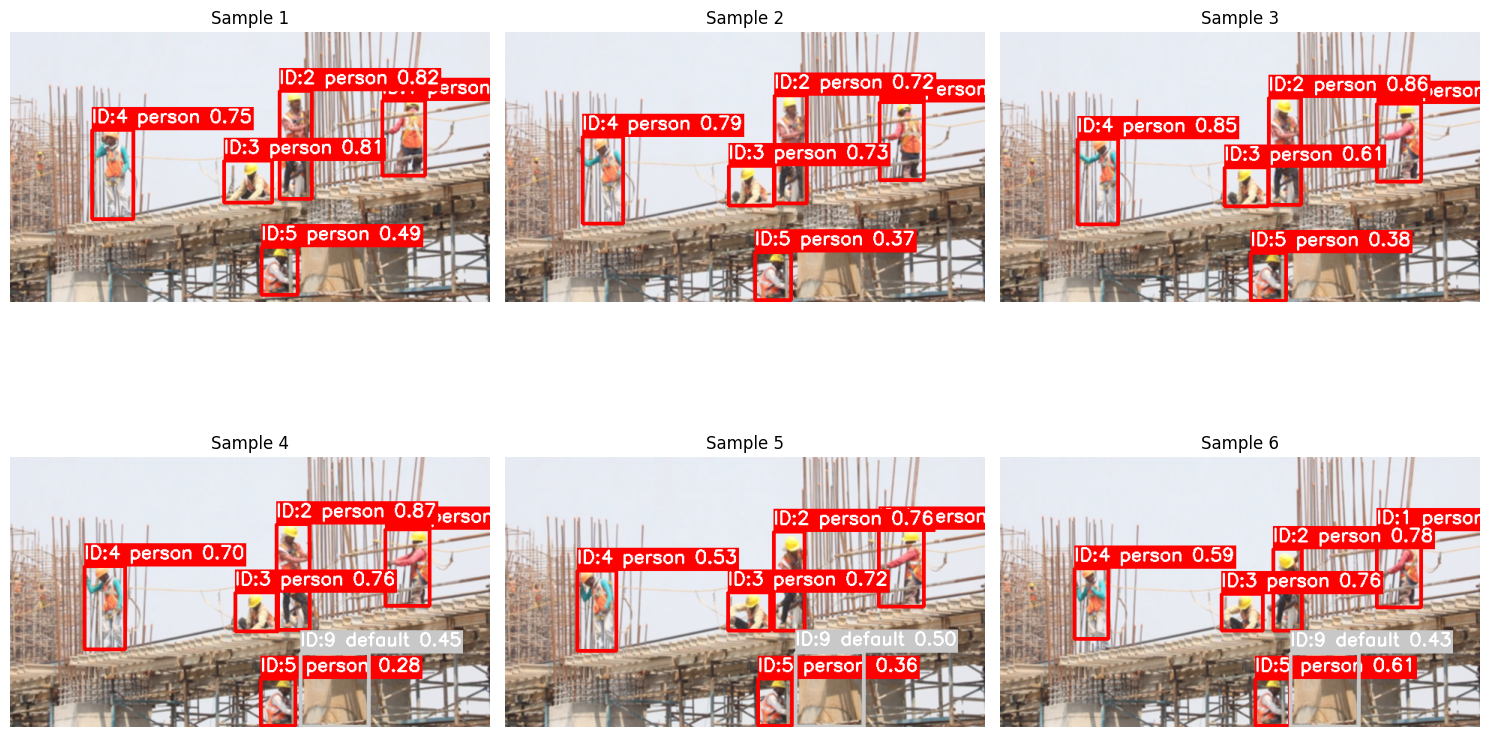

In [85]:
if 'sample_frames' in locals() and sample_frames:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(sample_frames):
            ax.imshow(sample_frames[i])
            ax.axis('off')
            ax.set_title(f"Sample {i+1}")
        else:
            ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No sample frames captured.")

**Gemini Video Reasoning**

In [86]:
try:
    if GEMINI_API_KEY != "YOUR_GEMINI_API_KEY_HERE":
        gemini = GeminiAnalyzer(GEMINI_API_KEY)

        # Analyze the ORIGINAL video for multimodal temporal reasoning
        safety_report = gemini.analyze_video(INPUT_VIDEO)

        with open("output/output_log.json", "w") as f:
            json.dump(safety_report, f, indent=4)

        print("\n📋 GEMINI SAFETY REPORT:")
        print(json.dumps(safety_report, indent=2))
    else:
        print("⚠️ Please configure your GEMINI_API_KEY in Cell 3 to run this analysis.")
except Exception as e:
    print(f"⚠️ Gemini Analysis Error: {e}")

⬆️ Uploading input5.mp4 to Gemini...
.
✅ Video processed. Running safety reasoning...

📋 GEMINI SAFETY REPORT:
{
  "site_status": "unsafe",
  "workers_detected": 5,
  "helmet_violations": 0,
  "workers": [
    {
      "worker_id": 1,
      "helmet_type": "worker_helmet",
      "ppe_violation": false,
      "movement_summary": "Standing on scaffolding, not wearing a safety harness.",
      "coordinates_detected": true,
      "safety_status": "unsafe"
    },
    {
      "worker_id": 2,
      "helmet_type": "worker_helmet",
      "ppe_violation": false,
      "movement_summary": "Kneeling while working on the structure.",
      "coordinates_detected": true,
      "safety_status": "safe"
    },
    {
      "worker_id": 3,
      "helmet_type": "worker_helmet",
      "ppe_violation": false,
      "movement_summary": "Standing, working with rebar.",
      "coordinates_detected": true,
      "safety_status": "safe"
    },
    {
      "worker_id": 4,
      "helmet_type": "worker_helmet",
      

**Radar** **Map** **Visualization**

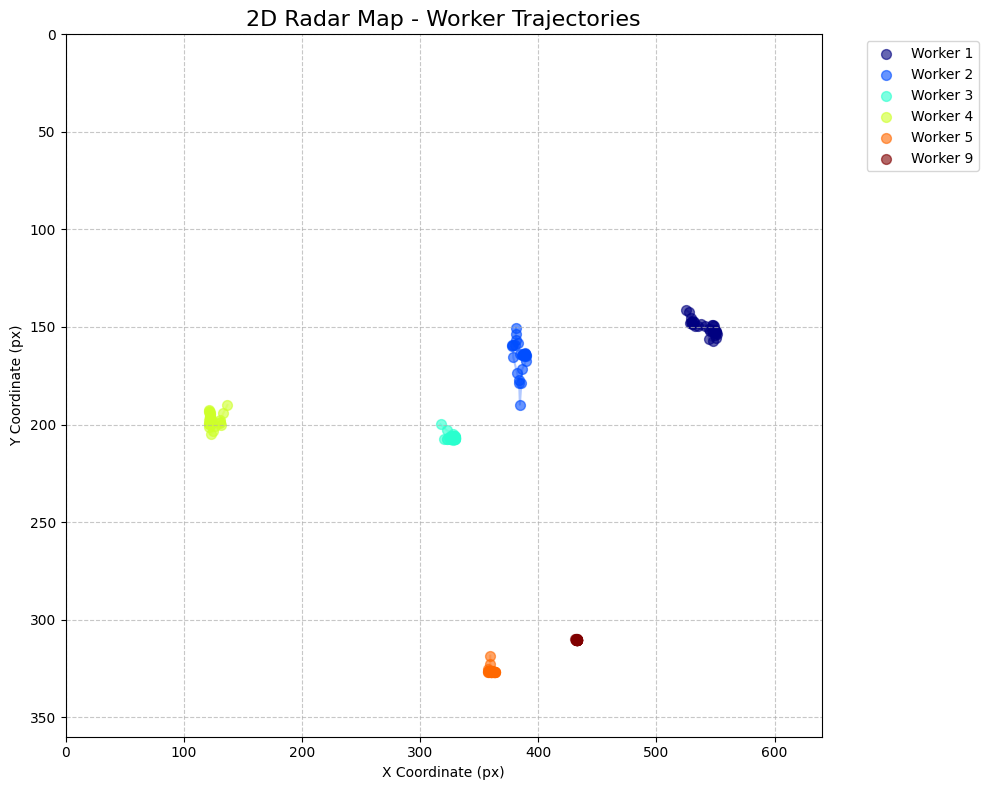

In [87]:
try:
    df = pd.read_csv("output/coordinates.csv")
    if not df.empty:
        plt.figure(figsize=(10, 8))
        plt.title("2D Radar Map - Worker Trajectories", fontsize=16)

        # Create scatter plot with unique colors per worker ID
        unique_ids = df['worker_id'].unique()
        colors = plt.cm.jet(np.linspace(0, 1, len(unique_ids)))

        for uid, col in zip(unique_ids, colors):
            worker_data = df[df['worker_id'] == uid]
            if uid == -1: col = 'gray' # Unassigned
            plt.scatter(worker_data['x'], worker_data['y'],
                        c=[col], label=f"Worker {uid}", alpha=0.6, s=50)
            plt.plot(worker_data['x'], worker_data['y'], c=col, alpha=0.3)

        plt.xlim(0, MAX_WIDTH)
        # Invert Y axis because image coordinates go top-to-bottom
        plt.ylim(video.new_h if 'video' in locals() and hasattr(video, 'new_h') else 480, 0)
        plt.xlabel("X Coordinate (px)")
        plt.ylabel("Y Coordinate (px)")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig("output/radar_map.png")
        plt.show()
    else:
        print("No coordinates logged. Radar map cannot be generated.")
except Exception as e:
    print(f"⚠️ Radar Map Error: {e}")

In [89]:
from google.colab import files
f = files.upload()

import subprocess
file0 = list(f.keys())[0]
_=subprocess.run(["pip", "install", "nbconvert"])
_=subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

files.download(file0[:-5]+ "html")

Saving Standalone_PPE_Project.ipynb to Standalone_PPE_Project (1).ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>